# Naive Bayes / Sentiment Analysis Project

# Clasificación de reseñas de Google Play con Naive Bayes

## Objetivo del proyecto

En este proyecto voy a construir un clasificador de sentimientos para reseñas de Google Play. La idea es predecir si una reseña es positiva o negativa a partir del texto escrito por el usuario.

El enfoque seguirá una lógica simple y progresiva:

- cargar y revisar el dataset;
- entender qué variables aportan al problema;
- preparar el texto para el modelado;
- probar las tres variantes de Naive Bayes vistas en clase;
- comparar resultados;
- elegir la opción más razonable y documentar la decisión.

La intención no es complicar innecesariamente el pipeline, sino construir una solución clara, defendible y consistente con lo trabajado en el bootcamp.

## 1. Carga inicial del dataset

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv"
df = pd.read_csv(url)

print(df.shape)
display(df.head())

print("\nInformación general del dataset:")
df.info()

(891, 3)


,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0



Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   package_name  891 non-null    str  
 1   review        891 non-null    str  
 2   polarity      891 non-null    int64
dtypes: int64(1), str(2)
memory usage: 21.0 KB


## 2. Revisión de variables y enfoque de modelado

Una vez cargado el dataset, el siguiente paso es revisar qué variables contiene y cuál de ellas aporta realmente al problema de clasificación.

En este caso, el objetivo es predecir si una reseña es positiva o negativa. Por eso, la variable más importante para el modelado es el texto de la reseña (`review`), ya que ahí está el contenido semántico que expresa el sentimiento del usuario.

La columna `package_name` puede aportar contexto sobre la aplicación, pero no describe directamente el tono de la opinión. Además, este proyecto busca construir un clasificador de texto sencillo y coherente con la lógica del módulo, así que el enfoque principal será trabajar con:

- `review` como variable predictora;
- `polarity` como variable objetivo.

### Decisión inicial

Después de revisar la estructura del dataset, el enfoque de trabajo será:

- conservar `review` como entrada principal del modelo;
- usar `polarity` como etiqueta binaria;
- dejar `package_name` fuera del modelado base, ya que para este caso añade menos valor que el propio contenido textual.

Esta decisión simplifica el pipeline y mantiene el proyecto alineado con un problema clásico de análisis de sentimiento.

### Notas de revisión de variables

- Número de filas y columnas: **891 filas y 3 columnas**
- Variables disponibles: **`package_name`, `review` y `polarity`**
- Valores nulos por columna: **no se detectaron valores nulos en ninguna de las tres variables**
- Distribución de la variable objetivo: **la clase `0` representa aproximadamente el 65.54% del dataset (584 registros) y la clase `1` el 34.46% (307 registros)**
- Observación inicial: **el dataset está limpio a nivel estructural, con reseñas en texto libre y una variable objetivo binaria ya definida. Aunque `package_name` identifica la aplicación, la información más útil para clasificar el sentimiento está en `review`. Además, la variable objetivo presenta cierto desbalance, por lo que conviene tenerlo en cuenta al comparar modelos.**

In [3]:
# Revisión general de estructura
print("Shape del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nInformación general:")
df.info()

# Valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Número de valores únicos por columna
print("\nValores únicos por columna:")
print(df.nunique())

# Distribución de la variable objetivo
print("\nDistribución de 'polarity' (conteo):")
print(df["polarity"].value_counts())

print("\nDistribución de 'polarity' (proporción):")
print(df["polarity"].value_counts(normalize=True))

# Muestra de observaciones
print("\nMuestra aleatoria de registros:")
display(df.sample(5, random_state=42))

# Algunas reseñas para inspección manual
print("\nEjemplos de reseñas:")
for i, text in enumerate(df["review"].dropna().head(3), start=1):
    print(f"\nReseña {i}:")
    print(text[:300], "...")

Shape del dataset: (891, 3)

Columnas:
['package_name', 'review', 'polarity']

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   package_name  891 non-null    str  
 1   review        891 non-null    str  
 2   polarity      891 non-null    int64
dtypes: int64(1), str(2)
memory usage: 21.0 KB

Valores nulos por columna:
package_name    0
review          0
polarity        0
dtype: int64

Valores únicos por columna:
package_name     23
review          891
polarity          2
dtype: int64

Distribución de 'polarity' (conteo):
polarity
0    584
1    307
Name: count, dtype: int64

Distribución de 'polarity' (proporción):
polarity
0    0.655443
1    0.344557
Name: proportion, dtype: float64

Muestra aleatoria de registros:


,package_name,review,polarity
709,com.opera.mini.native,love/hate has bug and security issues. i trie...,0
439,com.whatsapp,whatsapp i use this app now that blackberry m...,1
840,com.hamropatro,usefully verry nice app,1
720,com.opera.mini.native,fonts why in the heck is this thing analysing...,0
39,com.facebook.katana,app doesn't work after latest upgrade the fac...,0



Ejemplos de reseñas:

Reseña 1:
 privacy at least put some option appear offline. i mean for some people like me it's a big pressure to be seen online like you need to response on every message or else you be called seenzone only. if only i wanna do on facebook is to read on my newsfeed and just wanna response on message i want to ...

Reseña 2:
 messenger issues ever since the last update, initial received messages don't get pushed to the messenger app and you don't get notification in the facebook app or messenger app. you open the facebook app and happen to see you have a message. you have to click the icon and it opens messenger. subseq ...

Reseña 3:
 profile any time my wife or anybody has more than one post and i view them it would take me to there profile so that i can view them all at once. now when i try to view them it tells me that the page that i requested is not available. i've restarted my phone i even cleard the cache and i've uninsta ...


## 3. Preparación básica del texto

Después de revisar las variables, preparo una versión del dataset enfocada únicamente en el problema de clasificación de sentimiento.

En esta etapa conservo:

- `review` como texto de entrada;
- `polarity` como variable objetivo.

La limpieza aplicada aquí es intencionalmente simple. No busco transformar demasiado el texto, sino dejarlo en un formato consistente para la vectorización posterior. En concreto:

- convierto el texto a minúsculas;
- elimino espacios sobrantes al inicio y al final;
- normalizo espacios múltiples dentro de la reseña.

Dado que se trata de un pipeline base de clasificación de texto, prefiero evitar una limpieza excesiva antes de probar el modelo.

### Decisión de preprocesamiento

En este punto dejo fuera la variable `package_name` del modelado base. Aunque puede aportar contexto sobre la aplicación, el objetivo del proyecto es clasificar el sentimiento a partir del contenido de la reseña.

Por eso, el dataset de trabajo se construye solo con:

- `review_clean`: versión limpiada del texto;
- `polarity`: etiqueta binaria.

Antes de continuar, también verifico que la limpieza no haya generado textos vacíos.

### Observaciones de limpieza

- Columnas conservadas para modelado: **`review`, `polarity` y `review_clean`**
- Reseñas vacías después de limpiar: **0**
- Ejemplo antes/después de limpieza: **la limpieza eliminó espacios innecesarios al inicio y normalizó el formato del texto, manteniendo el contenido original. Por ejemplo, una reseña que empezaba con un espacio inicial pasó a una versión equivalente pero más consistente para el modelado.**
- Observación inicial: **la limpieza aplicada no alteró el contenido semántico de las reseñas y permitió generar una columna de texto lista para el siguiente paso. Además, no se produjeron textos vacíos, por lo que el dataset puede usarse directamente para hacer la partición entre entrenamiento y prueba.**

In [4]:
# Dataset de trabajo para modelado
df_ml = df[["review", "polarity"]].copy()

# Limpieza básica del texto
df_ml["review_clean"] = (
    df_ml["review"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Verificación de reseñas vacías después de limpiar
empty_reviews = (df_ml["review_clean"] == "").sum()

print("Columnas del dataset de modelado:")
print(df_ml.columns.tolist())

print("\nShape del dataset de modelado:")
print(df_ml.shape)

print("\nReseñas vacías después de limpiar:")
print(empty_reviews)

print("\nPrimeras filas del dataset de modelado:")
display(df_ml.head())

print("\nEjemplos antes y después de limpieza:")
sample_examples = df_ml[["review", "review_clean"]].head(3)

for i, row in sample_examples.iterrows():
    print(f"\nEjemplo {i}")
    print("Original:")
    print(row["review"][:250], "...")
    print("\nLimpio:")
    print(row["review_clean"][:250], "...")

Columnas del dataset de modelado:
['review', 'polarity', 'review_clean']

Shape del dataset de modelado:
(891, 3)

Reseñas vacías después de limpiar:
0

Primeras filas del dataset de modelado:


,review,polarity,review_clean
0,privacy at least put some option appear offli...,0,privacy at least put some option appear offlin...
1,"messenger issues ever since the last update, ...",0,"messenger issues ever since the last update, i..."
2,profile any time my wife or anybody has more ...,0,profile any time my wife or anybody has more t...
3,the new features suck for those of us who don...,0,the new features suck for those of us who don'...
4,forced reload on uploading pic on replying co...,0,forced reload on uploading pic on replying com...



Ejemplos antes y después de limpieza:

Ejemplo 0
Original:
 privacy at least put some option appear offline. i mean for some people like me it's a big pressure to be seen online like you need to response on every message or else you be called seenzone only. if only i wanna do on facebook is to read on my new ...

Limpio:
privacy at least put some option appear offline. i mean for some people like me it's a big pressure to be seen online like you need to response on every message or else you be called seenzone only. if only i wanna do on facebook is to read on my news ...

Ejemplo 1
Original:
 messenger issues ever since the last update, initial received messages don't get pushed to the messenger app and you don't get notification in the facebook app or messenger app. you open the facebook app and happen to see you have a message. you hav ...

Limpio:
messenger issues ever since the last update, initial received messages don't get pushed to the messenger app and you don't get notificat

## 4. Separación entre entrenamiento y prueba

Antes de vectorizar el texto, separo el dataset en conjuntos de entrenamiento y prueba.

Este orden es importante porque el vectorizador debe ajustarse únicamente con los datos de entrenamiento y luego aplicarse al conjunto de prueba. De esta forma, la evaluación del modelo se mantiene más realista y evita fuga de información.

En este caso, usaré:

- `review_clean` como variable predictora;
- `polarity` como variable objetivo;
- una partición de entrenamiento y prueba con estratificación para conservar la proporción de clases.

### Criterio de partición

La variable objetivo tiene un cierto desbalance, por lo que conviene usar `stratify` en el `train_test_split`. Así, tanto el conjunto de entrenamiento como el de prueba mantienen una distribución de clases parecida a la del dataset original.

Este paso deja preparado el pipeline para la vectorización con `CountVectorizer` en la siguiente sección.

### Observaciones del split

- Tamaño de `X_train`: **712 registros**
- Tamaño de `X_test`: **179 registros**
- Tamaño de `y_train`: **712 registros**
- Tamaño de `y_test`: **179 registros**
- Distribución de clases en entrenamiento: **la clase `0` tiene 467 registros (65.59%) y la clase `1` tiene 245 registros (34.41%)**
- Distribución de clases en prueba: **la clase `0` tiene 117 registros (65.36%) y la clase `1` tiene 62 registros (34.64%)**
- Observación inicial: **la partición se realizó correctamente y conservó de forma muy similar la proporción de clases del dataset original gracias al uso de `stratify`. Esto permite continuar con la vectorización sin introducir un sesgo adicional entre entrenamiento y prueba.**

In [5]:
from sklearn.model_selection import train_test_split

X = df_ml["review_clean"]
y = df_ml["polarity"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

print("\nDistribución de clases en y_train (conteo):")
print(y_train.value_counts())

print("\nDistribución de clases en y_train (proporción):")
print(y_train.value_counts(normalize=True))

print("\nDistribución de clases en y_test (conteo):")
print(y_test.value_counts())

print("\nDistribución de clases en y_test (proporción):")
print(y_test.value_counts(normalize=True))

print("\nEjemplo de reseña en entrenamiento:")
print(X_train.iloc[0][:300], "...")

print("\nEtiqueta asociada:")
print(y_train.iloc[0])

Tamaño de X_train: (712,)
Tamaño de X_test: (179,)
Tamaño de y_train: (712,)
Tamaño de y_test: (179,)

Distribución de clases en y_train (conteo):
polarity
0    467
1    245
Name: count, dtype: int64

Distribución de clases en y_train (proporción):
polarity
0    0.655899
1    0.344101
Name: proportion, dtype: float64

Distribución de clases en y_test (conteo):
polarity
0    117
1     62
Name: count, dtype: int64

Distribución de clases en y_test (proporción):
polarity
0    0.653631
1    0.346369
Name: proportion, dtype: float64

Ejemplo de reseña en entrenamiento:
best app i can't believe that it is free! they treat it as if you paid for it. ...

Etiqueta asociada:
1


## 5. Vectorización del texto

Una vez separados los datos en entrenamiento y prueba, el siguiente paso es transformar las reseñas en variables numéricas.

Para ello utilizo `CountVectorizer`, que convierte cada texto en una representación basada en frecuencias de palabras. En otras palabras, cada reseña pasa a describirse por las palabras que contiene y por cuántas veces aparecen.

En esta etapa es importante respetar el orden correcto del pipeline:

- el vectorizador se ajusta únicamente con `X_train`;
- después se aplica ese mismo vectorizador a `X_test`.

Así se evita fuga de información desde el conjunto de prueba.

### Criterio de vectorización

En esta primera versión del modelo usaré una vectorización simple, sin añadir todavía demasiadas decisiones de preprocesamiento.

El objetivo en esta fase es construir un baseline claro y fácil de interpretar. Más adelante, si tiene sentido, se podrán probar ajustes sobre el vectorizador como parte de la optimización del modelo final.

### Observaciones de la vectorización

- Tamaño de la matriz de entrenamiento: **(712, 3514)**
- Tamaño de la matriz de prueba: **(179, 3514)**
- Número de palabras en el vocabulario: **3514**
- Ejemplo de términos aprendidos: **`['04', '0x', '10', '100', '101', '11', '113mb', '1186', '12', '125', '13', '14', '15', '15mb', '16', '17', '180k', '1990s', '1day', '1lac']`**
- Observación inicial: **la vectorización se aplicó correctamente y generó una representación numérica consistente para entrenamiento y prueba, con el mismo número de variables en ambos conjuntos. Además, el resultado se almacenó como una matriz dispersa, lo que es adecuado para trabajar con texto y vocabularios relativamente amplios sin consumir memoria innecesaria.**

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# Vectorización del texto
vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Shape de X_train_vec:", X_train_vec.shape)
print("Shape de X_test_vec:", X_test_vec.shape)

vocab_size = len(vectorizer.vocabulary_)
print("\nNúmero de palabras en el vocabulario:", vocab_size)

feature_names = vectorizer.get_feature_names_out()
print("\nPrimeros 20 términos del vocabulario:")
print(feature_names[:20])

print("\nTipo de objeto generado:")
print(type(X_train_vec))

print("\nNúmero de valores no cero en X_train_vec:")
print(X_train_vec.nnz)

Shape de X_train_vec: (712, 3514)
Shape de X_test_vec: (179, 3514)

Número de palabras en el vocabulario: 3514

Primeros 20 términos del vocabulario:
['04' '0x' '10' '100' '101' '11' '113mb' '1186' '12' '125' '13' '14' '15'
 '15mb' '16' '17' '180k' '1990s' '1day' '1lac']

Tipo de objeto generado:
<class 'scipy.sparse._csr.csr_matrix'>

Número de valores no cero en X_train_vec:
22835


## 6. Modelo 1: Gaussian Naive Bayes

La primera implementación que pruebo es `GaussianNB`.

Este modelo asume que las variables siguen una distribución aproximadamente normal. En problemas de texto vectorizado esta suposición no suele ser la más natural, pero igualmente lo incluyo porque forma parte de las variantes pedidas en el proyecto y permite comparar comportamientos entre diferentes versiones de Naive Bayes.

Como `CountVectorizer` genera una matriz dispersa, para usar `GaussianNB` necesito convertir esa representación a formato denso antes de entrenar el modelo.

### Criterio de evaluación

Para esta primera prueba voy a revisar métricas básicas de clasificación sobre el conjunto de prueba:

- `accuracy`;
- `classification report`;
- matriz de confusión.

Con esto podré tener una primera referencia del rendimiento de `GaussianNB` antes de compararlo con las otras variantes.

### Resultados de GaussianNB

- Accuracy en test: **0.8268**
- Precision / Recall / F1-score: **para la clase 0, precision = 0.84, recall = 0.91 y f1-score = 0.87; para la clase 1, precision = 0.80, recall = 0.66 y f1-score = 0.73. El accuracy global fue 0.83, con un macro average f1 de 0.80 y weighted average f1 de 0.82.**
- Matriz de confusión: **[[107, 10], [21, 41]]**
- Observación inicial: **GaussianNB ofrece un rendimiento aceptable como primera referencia, pero muestra un mejor comportamiento sobre la clase 0 que sobre la clase 1. En particular, recupera bien los casos negativos, pero deja escapar una parte relevante de los positivos, por lo que conviene compararlo con otras implementaciones de Naive Bayes más naturales para datos de texto.**

Accuracy de GaussianNB:
0.8268156424581006

Classification report de GaussianNB:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       117
           1       0.80      0.66      0.73        62

    accuracy                           0.83       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.83      0.82       179

Matriz de confusión de GaussianNB:
[[107  10]
 [ 21  41]]


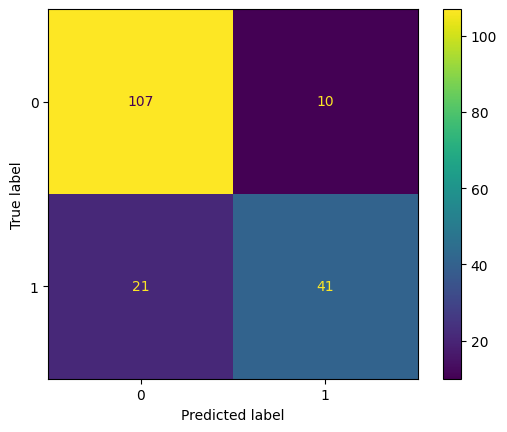

In [7]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Conversión de matrices dispersas a densas para GaussianNB
X_train_dense = X_train_vec.toarray()
X_test_dense = X_test_vec.toarray()

# Entrenamiento del modelo
gaussian_nb = GaussianNB()
gaussian_nb.fit(X_train_dense, y_train)

# Predicciones
y_pred_gnb = gaussian_nb.predict(X_test_dense)

# Métricas
gnb_accuracy = accuracy_score(y_test, y_pred_gnb)
gnb_report = classification_report(y_test, y_pred_gnb)
gnb_cm = confusion_matrix(y_test, y_pred_gnb)

print("Accuracy de GaussianNB:")
print(gnb_accuracy)

print("\nClassification report de GaussianNB:")
print(gnb_report)

print("Matriz de confusión de GaussianNB:")
print(gnb_cm)

# Visualización de matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=gnb_cm)
disp.plot()
plt.show()

## 7. Modelo 2: Multinomial Naive Bayes

La segunda implementación que pruebo es `MultinomialNB`.

Esta variante suele ser una opción más natural para clasificación de texto, ya que está pensada para trabajar con características discretas como conteos o frecuencias de palabras. Por eso encaja mejor con la salida de `CountVectorizer` que `GaussianNB`.

En esta prueba mantengo una configuración base, con el objetivo de comparar su comportamiento real frente al resto de implementaciones antes de pasar a cualquier ajuste adicional.

### Criterio de evaluación

Para mantener una comparación consistente entre modelos, evalúo `MultinomialNB` con las mismas métricas utilizadas en la sección anterior:

- `accuracy`;
- `classification report`;
- matriz de confusión.

Así podré comparar no solo la precisión global, sino también el equilibrio del modelo entre ambas clases.

### Resultados de MultinomialNB

- Accuracy en test: **0.8324**
- Precision / Recall / F1-score: **para la clase 0, precision = 0.82, recall = 0.96 y f1-score = 0.88; para la clase 1, precision = 0.88, recall = 0.60 y f1-score = 0.71. El accuracy global fue 0.83, con un macro average f1 de 0.80 y weighted average f1 de 0.82.**
- Matriz de confusión: **[[112, 5], [25, 37]]**
- Observación inicial: **MultinomialNB obtuvo un accuracy ligeramente superior al de GaussianNB y redujo los falsos positivos sobre la clase 0. Sin embargo, siguió mostrando dificultades para recuperar la clase 1, con un recall más bajo en los casos positivos. Por tanto, aunque el rendimiento global es competitivo, todavía conviene compararlo con BernoulliNB antes de elegir una opción final.**

Accuracy de MultinomialNB:
0.8324022346368715

Classification report de MultinomialNB:
              precision    recall  f1-score   support

           0       0.82      0.96      0.88       117
           1       0.88      0.60      0.71        62

    accuracy                           0.83       179
   macro avg       0.85      0.78      0.80       179
weighted avg       0.84      0.83      0.82       179

Matriz de confusión de MultinomialNB:
[[112   5]
 [ 25  37]]


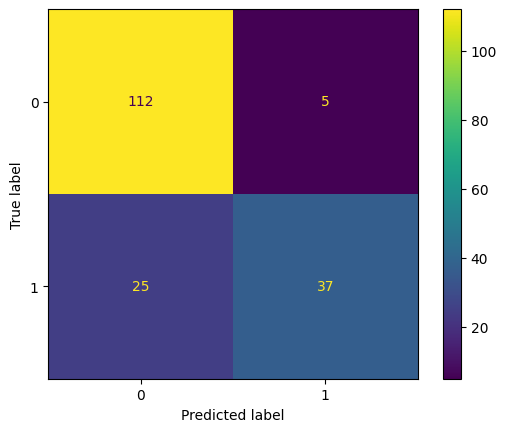

In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Entrenamiento del modelo
multinomial_nb = MultinomialNB()
multinomial_nb.fit(X_train_vec, y_train)

# Predicciones
y_pred_mnb = multinomial_nb.predict(X_test_vec)

# Métricas
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)
mnb_report = classification_report(y_test, y_pred_mnb)
mnb_cm = confusion_matrix(y_test, y_pred_mnb)

print("Accuracy de MultinomialNB:")
print(mnb_accuracy)

print("\nClassification report de MultinomialNB:")
print(mnb_report)

print("Matriz de confusión de MultinomialNB:")
print(mnb_cm)

# Visualización de matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=mnb_cm)
disp.plot()
plt.show()

## 8. Modelo 3: Bernoulli Naive Bayes

La tercera implementación que pruebo es `BernoulliNB`.

Este modelo está pensado para trabajar con variables binarias, es decir, casos en los que interesa más saber si una palabra aparece o no aparece en una reseña que el número exacto de veces que se repite.

Aunque el conjunto vectorizado proviene de conteos, igualmente incluyo esta variante para completar la comparación entre las tres implementaciones de Naive Bayes pedidas en el proyecto.

### Criterio de evaluación

Para mantener la comparación consistente, evalúo `BernoulliNB` con las mismas métricas usadas en los modelos anteriores:

- `accuracy`;
- `classification report`;
- matriz de confusión.

Así podré revisar si esta variante mejora el equilibrio entre clases o si confirma que otra implementación se ajusta mejor al problema.

### Resultados de BernoulliNB

- Accuracy en test: **0.8436**
- Precision / Recall / F1-score: **para la clase 0, precision = 0.82, recall = 0.98 y f1-score = 0.89; para la clase 1, precision = 0.95, recall = 0.58 y f1-score = 0.72. El accuracy global fue 0.84, con un macro average f1 de 0.81 y weighted average f1 de 0.83.**
- Matriz de confusión: **[[115, 2], [26, 36]]**
- Observación inicial: **BernoulliNB obtuvo el mejor accuracy global entre las tres implementaciones probadas y cometió muy pocos falsos positivos. Sin embargo, mostró una recuperación más limitada de la clase 1, lo que indica un comportamiento más conservador al identificar reseñas positivas. Por tanto, aunque su rendimiento general es sólido, la elección final debería considerar no solo el accuracy sino también el equilibrio entre precision y recall en la clase positiva.**

Accuracy de BernoulliNB:
0.8435754189944135

Classification report de BernoulliNB:
              precision    recall  f1-score   support

           0       0.82      0.98      0.89       117
           1       0.95      0.58      0.72        62

    accuracy                           0.84       179
   macro avg       0.88      0.78      0.81       179
weighted avg       0.86      0.84      0.83       179

Matriz de confusión de BernoulliNB:
[[115   2]
 [ 26  36]]


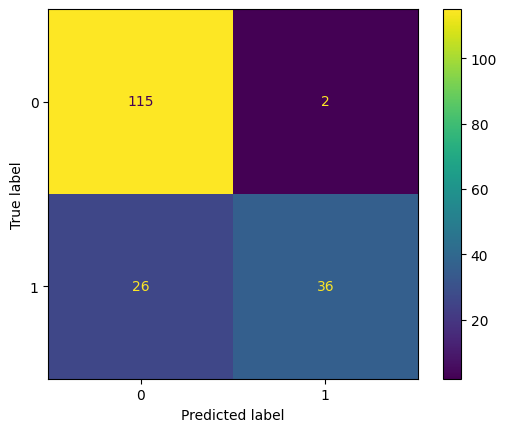

In [9]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Entrenamiento del modelo
bernoulli_nb = BernoulliNB()
bernoulli_nb.fit(X_train_vec, y_train)

# Predicciones
y_pred_bnb = bernoulli_nb.predict(X_test_vec)

# Métricas
bnb_accuracy = accuracy_score(y_test, y_pred_bnb)
bnb_report = classification_report(y_test, y_pred_bnb)
bnb_cm = confusion_matrix(y_test, y_pred_bnb)

print("Accuracy de BernoulliNB:")
print(bnb_accuracy)

print("\nClassification report de BernoulliNB:")
print(bnb_report)

print("Matriz de confusión de BernoulliNB:")
print(bnb_cm)

disp = ConfusionMatrixDisplay(confusion_matrix=bnb_cm)
disp.plot()
plt.show()

## 9. Comparación entre implementaciones de Naive Bayes

Después de entrenar las tres variantes pedidas en el proyecto, el siguiente paso es comparar sus resultados de forma conjunta.

La idea no es quedarme solo con el `accuracy`, sino revisar también cómo se comporta cada modelo en la clase positiva. En este tipo de problema, esa comparación importa porque un modelo puede acertar mucho en términos globales y aun así fallar más de lo deseable al recuperar una de las clases.

Por eso, en esta sección comparo:

- `accuracy`;
- precision, recall y f1-score de la clase 1;
- comportamiento general observado en la matriz de confusión.

### Criterio de comparación

Para elegir una opción final, voy a tener en cuenta dos niveles de análisis:

- rendimiento global del modelo;
- equilibrio entre precision y recall en la clase positiva.

Esto es importante porque las tres implementaciones no están fallando de la misma manera. Algunas maximizan más el accuracy total, mientras que otras recuperan mejor los casos positivos.

### Resumen comparativo

- Mejor accuracy global: **BernoulliNB, con un accuracy de 0.8436**
- Mejor recall en clase 1: **GaussianNB, con un recall de 0.6613**
- Modelo más conservador al predecir positivos: **BernoulliNB, ya que obtuvo la mayor precision en la clase 1 (0.9474), pero con un recall más bajo (0.5806)**
- Observación comparativa: **las tres implementaciones mostraron comportamientos distintos. BernoulliNB logró el mejor rendimiento global y cometió muy pocos falsos positivos, pero fue el más conservador al detectar positivos. GaussianNB no tuvo el mejor accuracy, aunque sí recuperó mejor la clase 1 y consiguió el mejor f1-score en esa clase. MultinomialNB quedó en una posición intermedia. Por tanto, si el criterio principal es el rendimiento global, BernoulliNB es la mejor base para optimizar; si se prioriza recuperar más positivos, GaussianNB resulta más equilibrado.**

In [10]:
from sklearn.metrics import classification_report
import pandas as pd

gnb_report_dict = classification_report(y_test, y_pred_gnb, output_dict=True)
mnb_report_dict = classification_report(y_test, y_pred_mnb, output_dict=True)
bnb_report_dict = classification_report(y_test, y_pred_bnb, output_dict=True)

comparison_df = pd.DataFrame({
    "model": ["GaussianNB", "MultinomialNB", "BernoulliNB"],
    "accuracy": [
        gnb_report_dict["accuracy"],
        mnb_report_dict["accuracy"],
        bnb_report_dict["accuracy"]
    ],
    "precision_class_1": [
        gnb_report_dict["1"]["precision"],
        mnb_report_dict["1"]["precision"],
        bnb_report_dict["1"]["precision"]
    ],
    "recall_class_1": [
        gnb_report_dict["1"]["recall"],
        mnb_report_dict["1"]["recall"],
        bnb_report_dict["1"]["recall"]
    ],
    "f1_class_1": [
        gnb_report_dict["1"]["f1-score"],
        mnb_report_dict["1"]["f1-score"],
        bnb_report_dict["1"]["f1-score"]
    ],
    "precision_class_0": [
        gnb_report_dict["0"]["precision"],
        mnb_report_dict["0"]["precision"],
        bnb_report_dict["0"]["precision"]
    ],
    "recall_class_0": [
        gnb_report_dict["0"]["recall"],
        mnb_report_dict["0"]["recall"],
        bnb_report_dict["0"]["recall"]
    ],
    "f1_class_0": [
        gnb_report_dict["0"]["f1-score"],
        mnb_report_dict["0"]["f1-score"],
        bnb_report_dict["0"]["f1-score"]
    ]
})

comparison_df = comparison_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)
display(comparison_df)

print("Modelo con mejor accuracy:")
print(comparison_df.loc[0, "model"])

print("\nModelo con mejor recall en clase 1:")
print(comparison_df.sort_values(by="recall_class_1", ascending=False).iloc[0]["model"])

print("\nModelo con mejor f1 en clase 1:")
print(comparison_df.sort_values(by="f1_class_1", ascending=False).iloc[0]["model"])

,model,accuracy,precision_class_1,recall_class_1,f1_class_1,precision_class_0,recall_class_0,f1_class_0
0,BernoulliNB,0.843575,0.947368,0.580645,0.720000,0.815603,0.982906,0.891473
1,MultinomialNB,0.832402,0.880952,0.596774,0.711538,0.817518,0.957265,0.881890
2,GaussianNB,0.826816,0.803922,0.661290,0.725664,0.835938,0.914530,0.873469


Modelo con mejor accuracy:
BernoulliNB

Modelo con mejor recall en clase 1:
GaussianNB

Modelo con mejor f1 en clase 1:
GaussianNB


## 10. Optimización del modelo seleccionado

A partir de la comparación anterior, tomo `BernoulliNB` como modelo base para una optimización ligera, ya que fue la implementación con mejor accuracy global.

De todos modos, la comparación también mostró que este modelo es más conservador al detectar la clase positiva. Por eso, en lugar de optimizar solo por accuracy, en esta etapa utilizaré una métrica más equilibrada durante la validación cruzada para intentar mejorar el comportamiento general entre ambas clases.

### Estrategia de ajuste

La optimización se mantendrá simple y razonable para el alcance del proyecto.

Los hiperparámetros que voy a probar son:

- `alpha`, que controla el suavizado;
- `fit_prior`, que indica si el modelo debe aprender las probabilidades a priori de las clases a partir de los datos.

Para seleccionar la mejor combinación usaré validación cruzada con `f1_macro`, ya que esta métrica penaliza mejor los desequilibrios entre clases que un accuracy puro.

### Resultados de la optimización

- Mejores hiperparámetros encontrados: **`alpha = 0.1` y `fit_prior = True`**
- Mejor score medio en validación cruzada: **0.7928 en `f1_macro`**
- Accuracy del modelo ajustado en test: **0.8492**
- Recall de la clase 1 tras el ajuste: **0.76**
- F1 de la clase 1 tras el ajuste: **0.78**
- Comparación con el modelo base: **el modelo ajustado mejoró ligeramente el accuracy global respecto a la versión base y, al mismo tiempo, mejoró de forma clara la capacidad de recuperar la clase positiva. En concreto, el recall de la clase 1 subió desde 0.58 hasta 0.76, lo que reduce el número de positivos no detectados. También mejoró el f1-score de esa clase, por lo que el ajuste sí aporta valor real al modelo.**
- Decisión final: **se conserva el modelo ajustado como modelo final del proyecto, ya que ofrece un mejor equilibrio entre rendimiento global y detección de la clase positiva.**

Mejores hiperparámetros:
{'alpha': 0.1, 'fit_prior': True}

Mejor score medio en validación cruzada (f1_macro):
0.7928040202483135

Accuracy de BernoulliNB ajustado:
0.8491620111731844

Classification report de BernoulliNB ajustado:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       117
           1       0.80      0.76      0.78        62

    accuracy                           0.85       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.85      0.85      0.85       179

Matriz de confusión de BernoulliNB ajustado:
[[105  12]
 [ 15  47]]


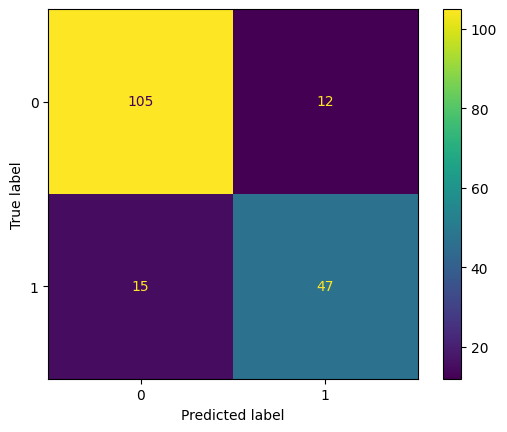


Comparación entre modelo base y ajustado:


,model_version,accuracy,precision_class_1,recall_class_1,f1_class_1
0,BernoulliNB_base,0.843575,0.947368,0.580645,0.72000
1,BernoulliNB_tuned,0.849162,0.796610,0.758065,0.77686


In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# Búsqueda simple de hiperparámetros
param_grid = {
    "alpha": [0.1, 0.5, 1.0, 2.0, 5.0],
    "fit_prior": [True, False]
}

grid_bnb = GridSearchCV(
    estimator=BernoulliNB(),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_bnb.fit(X_train_vec, y_train)

best_bnb = grid_bnb.best_estimator_

print("Mejores hiperparámetros:")
print(grid_bnb.best_params_)

print("\nMejor score medio en validación cruzada (f1_macro):")
print(grid_bnb.best_score_)

# Evaluación en test del modelo ajustado
y_pred_bnb_tuned = best_bnb.predict(X_test_vec)

bnb_tuned_accuracy = accuracy_score(y_test, y_pred_bnb_tuned)
bnb_tuned_report = classification_report(y_test, y_pred_bnb_tuned)
bnb_tuned_cm = confusion_matrix(y_test, y_pred_bnb_tuned)

print("\nAccuracy de BernoulliNB ajustado:")
print(bnb_tuned_accuracy)

print("\nClassification report de BernoulliNB ajustado:")
print(bnb_tuned_report)

print("Matriz de confusión de BernoulliNB ajustado:")
print(bnb_tuned_cm)

disp = ConfusionMatrixDisplay(confusion_matrix=bnb_tuned_cm)
disp.plot()
plt.show()

# Comparación rápida entre modelo base y modelo ajustado
bnb_base_report_dict = classification_report(y_test, y_pred_bnb, output_dict=True)
bnb_tuned_report_dict = classification_report(y_test, y_pred_bnb_tuned, output_dict=True)

tuning_comparison = pd.DataFrame({
    "model_version": ["BernoulliNB_base", "BernoulliNB_tuned"],
    "accuracy": [
        bnb_base_report_dict["accuracy"],
        bnb_tuned_report_dict["accuracy"]
    ],
    "precision_class_1": [
        bnb_base_report_dict["1"]["precision"],
        bnb_tuned_report_dict["1"]["precision"]
    ],
    "recall_class_1": [
        bnb_base_report_dict["1"]["recall"],
        bnb_tuned_report_dict["1"]["recall"]
    ],
    "f1_class_1": [
        bnb_base_report_dict["1"]["f1-score"],
        bnb_tuned_report_dict["1"]["f1-score"]
    ]
})

print("\nComparación entre modelo base y ajustado:")
display(tuning_comparison)

## 11. Guardado del modelo final

Una vez seleccionado el modelo final, el siguiente paso es guardarlo para poder reutilizarlo más adelante sin necesidad de reentrenarlo.

En este caso no solo guardo el clasificador, sino también el vectorizador, ya que ambos forman parte del pipeline real de predicción:

- el vectorizador transforma el texto en variables numéricas;
- el modelo utiliza esa representación para clasificar la reseña.

Guardar ambas piezas permite reconstruir el flujo completo de inferencia más adelante.

### Decisión de persistencia

El modelo final seleccionado es la versión ajustada de `BernoulliNB`.

Por tanto, voy a guardar:

- `vectorizer.pkl`
- `bernoulli_nb_tuned.pkl`

Ambos archivos se almacenarán en la carpeta `models/` para mantener una estructura clara dentro del proyecto.

### Resultado del guardado

- Archivo del vectorizador: **`../models/vectorizer.pkl`**
- Archivo del modelo: **`../models/bernoulli_nb_tuned.pkl`**
- Verificación de existencia: **ambos archivos se guardaron correctamente y `exists()` devolvió `True` en los dos casos**
- Observación final: **el proyecto ya cuenta con los dos componentes necesarios para reutilizar el pipeline de predicción: el vectorizador para transformar nuevas reseñas y el modelo ajustado para clasificarlas. Esto deja el entrenamiento listo para ser reutilizado sin necesidad de recalcular todo el proceso.**

In [12]:
import pickle
from pathlib import Path

# Crear carpeta models si no existe
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# Rutas de guardado
vectorizer_path = models_dir / "vectorizer.pkl"
model_path = models_dir / "bernoulli_nb_tuned.pkl"

# Guardar vectorizador
with open(vectorizer_path, "wb") as f:
    pickle.dump(vectorizer, f)

# Guardar modelo ajustado
with open(model_path, "wb") as f:
    pickle.dump(best_bnb, f)

print("Vectorizador guardado en:")
print(vectorizer_path)

print("\nModelo guardado en:")
print(model_path)

print("\n¿Existe el archivo del vectorizador?")
print(vectorizer_path.exists())

print("\n¿Existe el archivo del modelo?")
print(model_path.exists())

Vectorizador guardado en:
../models/vectorizer.pkl

Modelo guardado en:
../models/bernoulli_nb_tuned.pkl

¿Existe el archivo del vectorizador?
True

¿Existe el archivo del modelo?
True


## 12. Alternativa al enfoque Naive Bayes

Como contraste final, pruebo un modelo distinto a Naive Bayes para comprobar si otro enfoque puede ofrecer un rendimiento competitivo en esta tarea de clasificación de reseñas.

La alternativa elegida es `RandomForestClassifier`, un modelo basado en árboles de decisión que ya ha aparecido en otros ejercicios del bootcamp. Aunque no está especialmente diseñado para texto, puede servir como referencia adicional para evaluar si un enfoque más generalista logra capturar patrones útiles en los datos vectorizados.

### Justificación de la prueba

La intención de esta prueba no es sustituir automáticamente el modelo anterior, sino contrastarlo.

En problemas de texto con representación tipo bolsa de palabras, Naive Bayes suele funcionar bien como baseline por su simplicidad y eficiencia. Aun así, comparar con un modelo alternativo permite verificar si esa ventaja se mantiene en este dataset concreto o si otro enfoque logra mejorar alguna métrica relevante.

### Resultados de la alternativa

- Accuracy en test: **0.8045**
- Precision / Recall / F1-score: **para la clase 0, precision = 0.78, recall = 0.97 y f1-score = 0.87; para la clase 1, precision = 0.91, recall = 0.48 y f1-score = 0.63. El accuracy global fue 0.80, con un macro average f1 de 0.75 y weighted average f1 de 0.79.**
- Matriz de confusión: **[[114, 3], [32, 30]]**
- Comparación con el modelo final de Naive Bayes: **aunque Random Forest mantuvo una precision alta para la clase positiva, su recall fue claramente más bajo que el del BernoulliNB ajustado. En términos globales también obtuvo un accuracy inferior. Esto indica que fue un modelo más conservador al detectar positivos y menos equilibrado para este problema concreto.**
- Decisión: **esta alternativa no supera al modelo final de Naive Bayes, por lo que se mantiene `BernoulliNB` ajustado como la mejor opción del proyecto.**

Accuracy de Random Forest:
0.8044692737430168

Classification report de Random Forest:
              precision    recall  f1-score   support

           0       0.78      0.97      0.87       117
           1       0.91      0.48      0.63        62

    accuracy                           0.80       179
   macro avg       0.84      0.73      0.75       179
weighted avg       0.83      0.80      0.79       179

Matriz de confusión de Random Forest:
[[114   3]
 [ 32  30]]


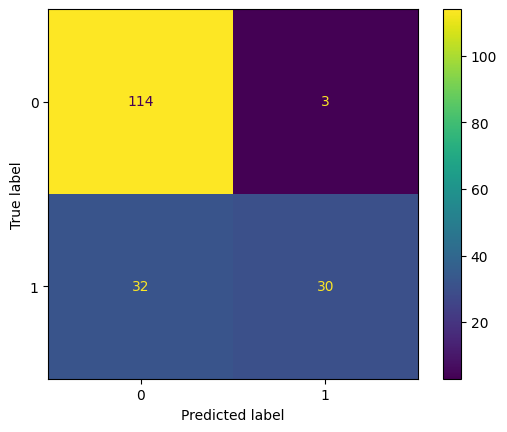

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Modelo alternativo
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_vec, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test_vec)

# Métricas
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf)
rf_cm = confusion_matrix(y_test, y_pred_rf)

print("Accuracy de Random Forest:")
print(rf_accuracy)

print("\nClassification report de Random Forest:")
print(rf_report)

print("Matriz de confusión de Random Forest:")
print(rf_cm)

disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm)
disp.plot()
plt.show()

## 13. Conclusión final

En este proyecto construí un clasificador de sentimiento para reseñas de Google Play utilizando un enfoque de procesamiento de texto sencillo y alineado con la lógica del bootcamp.

El flujo seguido fue:

- carga del dataset;
- revisión de variables;
- limpieza básica del texto;
- separación entre entrenamiento y prueba;
- vectorización con `CountVectorizer`;
- entrenamiento y comparación de las tres variantes de Naive Bayes;
- optimización ligera del mejor modelo;
- comparación final con una alternativa basada en `RandomForestClassifier`.

Después de comparar `GaussianNB`, `MultinomialNB` y `BernoulliNB`, la mejor base en términos de accuracy global fue `BernoulliNB`. Tras ajustar sus hiperparámetros, el modelo final mejoró tanto en rendimiento global como en capacidad para recuperar la clase positiva, por lo que fue la opción seleccionada para guardar y reutilizar.

### Modelo final seleccionado

El modelo final del proyecto fue **`BernoulliNB` ajustado** con:

- `alpha = 0.1`
- `fit_prior = True`

Este modelo obtuvo:

- **accuracy en test: 0.8492**
- **recall de la clase 1: 0.76**
- **f1-score de la clase 1: 0.78**

La elección no se hizo solo por accuracy. También se tuvo en cuenta que, tras el ajuste, el modelo mejoró de forma clara su equilibrio entre precision y recall en la clase positiva frente a la versión base.

### Reflexión final

Este proyecto confirma que, para una tarea de clasificación de texto con representación tipo bolsa de palabras, un modelo simple como Naive Bayes puede rendir muy bien y ser una solución sólida como baseline e incluso como modelo final.

La prueba con Random Forest sirvió como contraste, pero no superó al modelo ajustado en este dataset. Esto refuerza la idea de que, en problemas de texto con conteos de palabras y un volumen moderado de datos, un enfoque probabilístico bien planteado puede resultar más adecuado que modelos más complejos.

Como limitaciones, el proyecto mantiene una limpieza de texto deliberadamente simple y no explora técnicas más avanzadas como `TfidfVectorizer`, n-gramas o pipelines completos con validación más amplia. Aun así, para el alcance del ejercicio, el resultado final es consistente, interpretable y reutilizable.